## 1 - Packages

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import RandomOverSampler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Packages imported successfully!")

Packages imported successfully!


## 2 - SVM Theory and Implementation

### 2.1 SVM Fundamentals

**Objective:**
Find hyperplane $\mathbf{w} \cdot \mathbf{x} + b = 0$ that maximizes the margin between classes.

**Optimization Problem:**
$$\min_{\mathbf{w}, b} \frac{1}{2} ||\mathbf{w}||^2 + C \sum_{i=1}^{m} \max(0, 1 - y_i(\mathbf{w} \cdot \mathbf{x}_i + b))$$

where:
- $C$ is the regularization parameter (trade-off between margin width and misclassifications)
- Larger $C$ → harder margin (less tolerance for errors)
- Smaller $C$ → softer margin (more tolerance for errors)

**Linear Kernel:**
For high-dimensional text data, linear kernel is preferred:
- Linear: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$
- LinearSVC is fast and scales well to large feature spaces
- Text features after TF-IDF vectorization are typically linearly separable
- Optimal C parameter balances margin width and training error

### 2.2 Implementation Overview

This notebook implements Linear SVM with **optimal hyperparameters** from hyperparameter tuning to classify MBTI personality dimensions.

#### **Approach:**

1. **Load Optimal Hyperparameters**
   - Import best C values from `svm_hyperparameter_tuning.ipynb`
   - Each dimension has its own optimal C parameter
   - Parameters determined through GridSearchCV with 5-fold cross-validation
   - Uses upsampling to ensure balanced learning

2. **Linear SVM with Upsampling**
   - RandomOverSampler to balance training data
   - LinearSVC with dimension-specific optimal C values
   - Minority class duplicated to match majority
   - **Goal**: Achieve balanced performance across all classes

#### **Evaluation Strategy:**

- **Metrics**: F1-score, Recall, Specificity, Accuracy
- **Why**: Accuracy alone is misleading with imbalanced data
- **Focus**: Balance between catching minority class (recall) and avoiding false positives (specificity)

#### **Expected Outcomes:**

- Linear SVM should perform well (text data is high-dimensional and often linearly separable)
- Upsampling/class weights should improve minority class recall
- RBF may not justify computational cost for this task

### 2.3 Load Data

In [20]:
# Load preprocessed data
X = joblib.load('../data/processed/X_vectorized.pkl')
Y = joblib.load('../data/processed/Y_labels.pkl')
vectorizer = joblib.load('../data/processed/vectorizer.pkl')
label_encoder = joblib.load('../data/processed/label_encoder.pkl')

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nSparse matrix format: {type(X)}")

X shape: (8462, 90493)
Y shape: (8462,)
Number of features: 90493
Number of samples: 8462

Sparse matrix format: <class 'scipy.sparse._csr.csr_matrix'>


## 3 - Binary Classification for MBTI Dimensions

We'll train SVM classifiers for each of the 4 MBTI dimensions.

In [21]:
# Extract binary labels for each dimension
personality_types = label_encoder.inverse_transform(Y)

dimensions = {
    'I/E': np.array([1 if pt[0] == 'I' else 0 for pt in personality_types]),
    'N/S': np.array([1 if pt[1] == 'N' else 0 for pt in personality_types]),
    'T/F': np.array([1 if pt[2] == 'T' else 0 for pt in personality_types]),
    'J/P': np.array([1 if pt[3] == 'J' else 0 for pt in personality_types])
}

# Print distributions
print("=" * 60)
print("DIMENSION DISTRIBUTIONS")
print("=" * 60)
for dim_name, labels in dimensions.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)
    pct_pos = 100 * n_pos / len(labels)
    print(f"{dim_name}: {pos_class}={n_pos} ({pct_pos:.1f}%), {neg_class}={n_neg} ({100-pct_pos:.1f}%)")
print("=" * 60)

DIMENSION DISTRIBUTIONS
I/E: I=6534 (77.2%), E=1928 (22.8%)
N/S: N=7284 (86.1%), S=1178 (13.9%)
T/F: T=3907 (46.2%), F=4555 (53.8%)
J/P: J=3365 (39.8%), P=5097 (60.2%)


### 3.1 SVM Configuration

We'll compare two SVM approaches:
1. **LinearSVC**: Fast linear SVM optimized for large datasets
2. **SVC with RBF kernel**: More flexible but slower (for comparison)

**Hyperparameter C:**
- Controls trade-off between smooth decision boundary and classifying training points correctly
- Default C=1.0 is a good starting point

In [22]:
# Load optimal hyperparameters from tuning notebook
try:
    with open('../models/optimal_hyperparameters_svm.json', 'r') as f:
        optimal_params_svm = json.load(f)
    print("✅ Loaded optimal SVM hyperparameters from JSON")
    print("\nOptimal C values per dimension:")
    for dim, params in optimal_params_svm.items():
        print(f"  {dim}: C={params['best_C']}")
except FileNotFoundError:
    print("⚠️  optimal_hyperparameters_svm.json not found. Using default C=0.1 for all dimensions.")
    optimal_params_svm = {
        'I/E': {'best_C': 0.1},
        'N/S': {'best_C': 0.1},
        'T/F': {'best_C': 0.1},
        'J/P': {'best_C': 0.1}
    }

# Global parameters
MAX_ITER = 1000
RANDOM_STATE = 42

print(f"\nGlobal settings: max_iter={MAX_ITER}, random_state={RANDOM_STATE}")

✅ Loaded optimal SVM hyperparameters from JSON

Optimal C values per dimension:
  I/E: C=0.5
  J/P: C=0.5
  N/S: C=0.5
  T/F: C=0.5

Global settings: max_iter=1000, random_state=42


### 3.2 Train Linear SVM for All Dimensions

In [23]:
# Store results
results_linear = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM: {dim_name}")
    print("=" * 80)
    
    # Get optimal C for this dimension
    C_optimal = optimal_params_svm[dim_name]['best_C']
    print(f"Using optimal C={C_optimal} (from hyperparameter tuning)")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Train Linear SVM with optimal hyperparameters
    print(f"\nTraining LinearSVC...")
    svm_linear = LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False)
    svm_linear.fit(X_train, y_train)
    
    # Evaluate
    y_pred_test = svm_linear.predict(X_test)
    y_pred_train = svm_linear.predict(X_train)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False), 
                                        X_train, y_train, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear[dim_name] = {
        'model': svm_linear,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,  # LinearSVC doesn't expose support vectors directly
        # New comprehensive metrics
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults:")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  F1 Score: {f1:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")
    print(f"  Number of features: {X_train.shape[1]:,}")


TRAINING LINEAR SVM: I/E
Using optimal C=0.5 (from hyperparameter tuning)

Training LinearSVC...

Results:
  Accuracy: 76.85%
  F1 Score: 86.76%
  Baseline (majority): 77.20%
  Improvement over baseline: -0.35%
  Number of features: 90,493

TRAINING LINEAR SVM: N/S
Using optimal C=0.5 (from hyperparameter tuning)

Training LinearSVC...

Results:
  Accuracy: 86.24%
  F1 Score: 92.60%
  Baseline (majority): 86.06%
  Improvement over baseline: +0.18%
  Number of features: 90,493

TRAINING LINEAR SVM: T/F
Using optimal C=0.5 (from hyperparameter tuning)

Training LinearSVC...

Results:
  Accuracy: 75.84%
  F1 Score: 73.32%
  Baseline (majority): 53.81%
  Improvement over baseline: +22.03%
  Number of features: 90,493

TRAINING LINEAR SVM: J/P
Using optimal C=0.5 (from hyperparameter tuning)

Training LinearSVC...

Results:
  Accuracy: 64.38%
  F1 Score: 39.76%
  Baseline (majority): 60.25%
  Improvement over baseline: +4.13%
  Number of features: 90,493


### 3.2b Train Linear SVM with Upsampling (for comparison)


In [24]:
# Store upsampled results
results_linear_upsampled = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM WITH UPSAMPLING: {dim_name}")
    print("=" * 80)
    
    # Get optimal C for this dimension
    C_optimal = optimal_params_svm[dim_name]['best_C']
    print(f"Using optimal C={C_optimal} (from hyperparameter tuning)")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Apply upsampling to training data
    print(f"Original training set distribution:")
    print(f"  Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
    
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_train_upsampled, y_train_upsampled = ros.fit_resample(X_train, y_train)
    
    print(f"After upsampling:")
    print(f"  Class 0: {np.sum(y_train_upsampled == 0)}, Class 1: {np.sum(y_train_upsampled == 1)}")
    
    # Train Linear SVM on upsampled data with optimal hyperparameters
    print(f"\nTraining LinearSVC on upsampled data...")
    svm_linear_up = LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False)
    svm_linear_up.fit(X_train_upsampled, y_train_upsampled)
    
    # Evaluate
    y_pred_test = svm_linear_up.predict(X_test)
    y_pred_train = svm_linear_up.predict(X_train_upsampled)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train_upsampled, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, dual=False), 
                                        X_train_upsampled, y_train_upsampled, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear_upsampled[dim_name] = {
        'model': svm_linear_up,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults (Upsampled):")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  F1-Score: {f1:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")


TRAINING LINEAR SVM WITH UPSAMPLING: I/E
Using optimal C=0.5 (from hyperparameter tuning)
Original training set distribution:
  Class 0: 1542, Class 1: 5227
After upsampling:
  Class 0: 5227, Class 1: 5227

Training LinearSVC on upsampled data...

Results (Upsampled):
  Accuracy: 75.01%
  F1-Score: 84.19%
  Baseline (majority): 77.20%
  Improvement over baseline: -2.19%

TRAINING LINEAR SVM WITH UPSAMPLING: N/S
Using optimal C=0.5 (from hyperparameter tuning)
Original training set distribution:
  Class 0: 942, Class 1: 5827
After upsampling:
  Class 0: 5827, Class 1: 5827

Training LinearSVC on upsampled data...

Results (Upsampled):
  Accuracy: 84.58%
  F1-Score: 91.16%
  Baseline (majority): 86.06%
  Improvement over baseline: -1.48%

TRAINING LINEAR SVM WITH UPSAMPLING: T/F
Using optimal C=0.5 (from hyperparameter tuning)
Original training set distribution:
  Class 0: 3644, Class 1: 3125
After upsampling:
  Class 0: 3644, Class 1: 3644

Training LinearSVC on upsampled data...

Resu

### 3.2c Train Linear SVM with Class Weights (for comparison)

In [ ]:
# Store class weights results
results_linear_weights = {}

for dim_name, Y_binary in dimensions.items():
    print("\n" + "=" * 80)
    print(f"TRAINING LINEAR SVM WITH CLASS WEIGHTS: {dim_name}")
    print("=" * 80)
    
    # Get optimal C for this dimension
    # C_optimal = optimal_params_svm[dim_name]['best_C']
    C_optimal = 0.01
    print(f"Using optimal C={C_optimal} (from hyperparameter tuning)")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Show class distribution
    print(f"Training set distribution:")
    print(f"  Class 0: {np.sum(y_train == 0)}, Class 1: {np.sum(y_train == 1)}")
    
    # Train Linear SVM with class weights and optimal hyperparameters
    print(f"\nTraining LinearSVC with class_weight='balanced'...")
    svm_linear_weights = LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, 
                                    dual=False, class_weight='balanced')
    svm_linear_weights.fit(X_train, y_train)
    
    # Evaluate
    y_pred_test = svm_linear_weights.predict(X_test)
    y_pred_train = svm_linear_weights.predict(X_train)
    accuracy = np.mean(y_pred_test == y_test) * 100
    
    # Calculate comprehensive metrics
    train_accuracy = 100 * accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy
    f1 = 100 * f1_score(y_test, y_pred_test, zero_division=0)
    precision = 100 * precision_score(y_test, y_pred_test, zero_division=0)
    recall = 100 * recall_score(y_test, y_pred_test, zero_division=0)
    overfit_gap = train_accuracy - test_accuracy
    
    # Cross-validation score
    try:
        cv_score = 100 * cross_val_score(LinearSVC(C=C_optimal, max_iter=MAX_ITER, random_state=RANDOM_STATE, 
                                                     dual=False, class_weight='balanced'), 
                                        X_train, y_train, cv=5, scoring='f1').mean()
    except:
        cv_score = np.nan
    
    # Baseline
    baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
    # Store results
    results_linear_weights[dim_name] = {
        'model': svm_linear_weights,
        'accuracy': accuracy,
        'baseline': baseline,
        'y_test': y_test,
        'y_pred': y_pred_test,
        'n_support': None,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'overfit_gap': overfit_gap,
        'cv_score': cv_score
    }
    
    print(f"\nResults (Class Weights):")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  F1-Score: {f1:.2f}%")
    print(f"  Baseline (majority): {baseline:.2f}%")
    print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")


TRAINING LINEAR SVM WITH CLASS WEIGHTS: I/E
Using optimal C=0.5 (from hyperparameter tuning)
Training set distribution:
  Class 0: 1542, Class 1: 5227

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 74.19%
  F1-Score: 83.40%
  Baseline (majority): 77.20%
  Improvement over baseline: -3.01%

TRAINING LINEAR SVM WITH CLASS WEIGHTS: N/S
Using optimal C=0.5 (from hyperparameter tuning)
Training set distribution:
  Class 0: 942, Class 1: 5827

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 82.93%
  F1-Score: 90.07%
  Baseline (majority): 86.06%
  Improvement over baseline: -3.13%

TRAINING LINEAR SVM WITH CLASS WEIGHTS: T/F
Using optimal C=0.5 (from hyperparameter tuning)
Training set distribution:
  Class 0: 3644, Class 1: 3125

Training LinearSVC with class_weight='balanced'...

Results (Class Weights):
  Accuracy: 76.49%
  F1-Score: 75.12%
  Baseline (majority): 53.81%
  Improvement over baseline: +22.68

### 3.3 Train RBF SVM for Comparison

RBF (Radial Basis Function) kernel can capture non-linear patterns.

**Note:** This is computationally expensive for large datasets. We'll train on a subset for demonstration.

In [26]:
# # For RBF, we'll use a subset of data due to computational constraints
# SUBSET_SIZE = 2000  # Use 2000 samples for RBF demo

# results_rbf = {}

# for dim_name, Y_binary in dimensions.items():
#     print("\n" + "=" * 80)
#     print(f"TRAINING RBF SVM: {dim_name} (on subset)")
#     print("=" * 80)
    
#     # Split data
#     X_train, X_test, y_train, y_test = train_test_split(
#         X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
#     )
    
#     # Use subset for RBF
#     if len(y_train) > SUBSET_SIZE:
#         indices = np.random.RandomState(RANDOM_STATE).choice(len(y_train), SUBSET_SIZE, replace=False)
#         X_train_subset = X_train[indices]
#         y_train_subset = y_train[indices]
#         print(f"Using {SUBSET_SIZE} training samples for RBF SVM")
#     else:
#         X_train_subset = X_train
#         y_train_subset = y_train
    
#     # Train RBF SVM
#     print(f"Training SVC with RBF kernel...")
#     svm_rbf = SVC(C=C_PARAM, kernel='rbf', gamma='scale', random_state=RANDOM_STATE, max_iter=MAX_ITER)
#     svm_rbf.fit(X_train_subset, y_train_subset)
    
#     # Evaluate
#     y_pred = svm_rbf.predict(X_test)
#     accuracy = np.mean(y_pred == y_test) * 100
    
#     # Baseline
#     baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
    
#     # Store results
#     results_rbf[dim_name] = {
#         'model': svm_rbf,
#         'accuracy': accuracy,
#         'baseline': baseline,
#         'y_test': y_test,
#         'y_pred': y_pred,
#         'n_support': svm_rbf.n_support_
#     }
    
#     print(f"\nResults:")
#     print(f"  Accuracy: {accuracy:.2f}%")
#     print(f"  Baseline (majority): {baseline:.2f}%")
#     print(f"  Improvement over baseline: {accuracy - baseline:+.2f}%")
#     print(f"  Number of support vectors: {sum(svm_rbf.n_support_)}")
#     print(f"  Training samples used: {len(y_train_subset):,}")

## 4 - Results Summary

In [27]:
print("=" * 80)
print("SVM CLASSIFICATION RESULTS - ALL MBTI DIMENSIONS")
print("=" * 80)
print(f"\nDataset: {X.shape[0]:,} samples, {X.shape[1]:,} features")
print(f"Using optimal hyperparameters from GridSearchCV")

print("\n" + "=" * 80)
print("LINEAR SVM WITH OPTIMAL HYPERPARAMETERS")
print("=" * 80)
print(f"{'Dimension':<12} {'Optimal C':<12} {'Accuracy':<12} {'Baseline':<12} {'Improvement':<15}")
print("-" * 80)

for dim_name, res in results_linear.items():
    improvement = res['accuracy'] - res['baseline']
    C_opt = optimal_params_svm[dim_name]['best_C']
    print(f"{dim_name:<12} {C_opt:>10.3f}   {res['accuracy']:>6.2f}%      {res['baseline']:>6.2f}%      {improvement:>+6.2f}%")

print("=" * 80)

# Average performance Linear SVM
avg_linear = np.mean([r['accuracy'] for r in results_linear.values()])
avg_baseline = np.mean([r['baseline'] for r in results_linear.values()])

print(f"\nAverage Linear SVM: {avg_linear:.2f}%")
print(f"Average Baseline: {avg_baseline:.2f}%")
print(f"Average Improvement: {avg_linear - avg_baseline:+.2f}%")
print("=" * 80)

SVM CLASSIFICATION RESULTS - ALL MBTI DIMENSIONS

Dataset: 8,462 samples, 90,493 features
Using optimal hyperparameters from GridSearchCV

LINEAR SVM WITH OPTIMAL HYPERPARAMETERS
Dimension    Optimal C    Accuracy     Baseline     Improvement    
--------------------------------------------------------------------------------
I/E               0.500    76.85%       77.20%       -0.35%
N/S               0.500    86.24%       86.06%       +0.18%
T/F               0.500    75.84%       53.81%      +22.03%
J/P               0.500    64.38%       60.25%       +4.13%

Average Linear SVM: 75.83%
Average Baseline: 69.33%
Average Improvement: +6.50%


In [28]:
# Compare all three approaches side-by-side
print("\n" + "=" * 120)
print("COMPARISON: ALL THREE APPROACHES (Optimal C vs Upsampled vs Class Weights)")
print("=" * 120)
print(f"{'Dimension':<12} {'Original (C only)':<30} {'Upsampled (C + ROS)':<30} {'Class Weights (C + balanced)':<30}")
print(f"{'':12} {'F1':<10} {'Recall':<10} {'Spec':<10} {'F1':<10} {'Recall':<10} {'Spec':<10} {'F1':<10} {'Recall':<10} {'Spec':<10}")
print("-" * 120)

for dim_name in ['I/E', 'N/S', 'T/F', 'J/P']:
    # Original metrics
    orig_f1 = results_linear[dim_name]['f1_score']
    orig_recall = results_linear[dim_name]['recall']
    # Calculate specificity for original
    cm_orig = confusion_matrix(results_linear[dim_name]['y_test'], results_linear[dim_name]['y_pred'])
    tn_o, fp_o, fn_o, tp_o = cm_orig.ravel()
    orig_spec = 100 * (tn_o / (tn_o + fp_o)) if (tn_o + fp_o) > 0 else 0
    
    # Upsampled metrics
    upsample_f1 = results_linear_upsampled[dim_name]['f1_score']
    upsample_recall = results_linear_upsampled[dim_name]['recall']
    # Calculate specificity for upsampled
    cm_up = confusion_matrix(results_linear_upsampled[dim_name]['y_test'], results_linear_upsampled[dim_name]['y_pred'])
    tn_u, fp_u, fn_u, tp_u = cm_up.ravel()
    upsample_spec = 100 * (tn_u / (tn_u + fp_u)) if (tn_u + fp_u) > 0 else 0
    
    # Class weights metrics
    weights_f1 = results_linear_weights[dim_name]['f1_score']
    weights_recall = results_linear_weights[dim_name]['recall']
    # Calculate specificity for class weights
    cm_w = confusion_matrix(results_linear_weights[dim_name]['y_test'], results_linear_weights[dim_name]['y_pred'])
    tn_w, fp_w, fn_w, tp_w = cm_w.ravel()
    weights_spec = 100 * (tn_w / (tn_w + fp_w)) if (tn_w + fp_w) > 0 else 0
    
    # Print comparison
    print(f"{dim_name:<12} "
          f"{orig_f1:>6.2f}%    {orig_recall:>6.2f}%    {orig_spec:>6.2f}%    "
          f"{upsample_f1:>6.2f}%    {upsample_recall:>6.2f}%    {upsample_spec:>6.2f}%    "
          f"{weights_f1:>6.2f}%    {weights_recall:>6.2f}%    {weights_spec:>6.2f}%")

print("-" * 120)

# Calculate averages
avg_orig_f1 = np.mean([r['f1_score'] for r in results_linear.values()])
avg_upsample_f1 = np.mean([r['f1_score'] for r in results_linear_upsampled.values()])
avg_weights_f1 = np.mean([r['f1_score'] for r in results_linear_weights.values()])

avg_orig_recall = np.mean([r['recall'] for r in results_linear.values()])
avg_upsample_recall = np.mean([r['recall'] for r in results_linear_upsampled.values()])
avg_weights_recall = np.mean([r['recall'] for r in results_linear_weights.values()])

# Calculate average specificity for each approach
orig_specs = []
upsample_specs = []
weights_specs = []
for dim_name in ['I/E', 'N/S', 'T/F', 'J/P']:
    # Original
    cm = confusion_matrix(results_linear[dim_name]['y_test'], results_linear[dim_name]['y_pred'])
    tn, fp = cm.ravel()[0], cm.ravel()[1]
    orig_specs.append(100 * (tn / (tn + fp)) if (tn + fp) > 0 else 0)
    
    # Upsampled
    cm = confusion_matrix(results_linear_upsampled[dim_name]['y_test'], results_linear_upsampled[dim_name]['y_pred'])
    tn, fp = cm.ravel()[0], cm.ravel()[1]
    upsample_specs.append(100 * (tn / (tn + fp)) if (tn + fp) > 0 else 0)
    
    # Class weights
    cm = confusion_matrix(results_linear_weights[dim_name]['y_test'], results_linear_weights[dim_name]['y_pred'])
    tn, fp = cm.ravel()[0], cm.ravel()[1]
    weights_specs.append(100 * (tn / (tn + fp)) if (tn + fp) > 0 else 0)

avg_orig_spec = np.mean(orig_specs)
avg_upsample_spec = np.mean(upsample_specs)
avg_weights_spec = np.mean(weights_specs)

print(f"{'AVERAGE':<12} "
      f"{avg_orig_f1:>6.2f}%    {avg_orig_recall:>6.2f}%    {avg_orig_spec:>6.2f}%    "
      f"{avg_upsample_f1:>6.2f}%    {avg_upsample_recall:>6.2f}%    {avg_upsample_spec:>6.2f}%    "
      f"{avg_weights_f1:>6.2f}%    {avg_weights_recall:>6.2f}%    {avg_weights_spec:>6.2f}%")

print("=" * 120)

# Determine best approach based on F1-score
best_approach = max(
    [("Original (C only)", avg_orig_f1),
     ("Upsampled (C + ROS)", avg_upsample_f1),
     ("Class Weights (C + balanced)", avg_weights_f1)],
    key=lambda x: x[1]
)

print(f"\n BEST APPROACH: {best_approach[0]} with average F1-score of {best_approach[1]:.2f}%")

# Key insights
print("\n KEY INSIGHTS:")
print(f"  • Original approach: High specificity ({avg_orig_spec:.1f}%) but low recall ({avg_orig_recall:.1f}%) → Lazy model")
print(f"  • Upsampled approach: Balanced recall ({avg_upsample_recall:.1f}%) and specificity ({avg_upsample_spec:.1f}%) → Better F1")
print(f"  • Class Weights approach: Recall ({avg_weights_recall:.1f}%) and specificity ({avg_weights_spec:.1f}%)")
print(f"\n  Without upsampling/class weights, models tend to predict only the majority class!")
print("=" * 120)


COMPARISON: ALL THREE APPROACHES (Optimal C vs Upsampled vs Class Weights)
Dimension    Original (C only)              Upsampled (C + ROS)            Class Weights (C + balanced)  
             F1         Recall     Spec       F1         Recall     Spec       F1         Recall     Spec      
------------------------------------------------------------------------------------------------------------------------
I/E           86.76%     98.24%      4.40%     84.19%     86.15%     37.31%     83.40%     84.01%     40.93%
N/S           92.60%    100.00%      1.27%     91.16%     92.38%     36.44%     90.07%     89.98%     39.41%
T/F           73.32%     71.87%     79.25%     74.92%     76.21%     76.62%     75.12%     76.85%     76.18%
J/P           39.76%     29.57%     87.35%     52.07%     50.52%     71.27%     53.34%     53.94%     68.14%
------------------------------------------------------------------------------------------------------------------------
AVERAGE       73.11%     74.

### 4.1 Confusion Matrices - Linear SVM

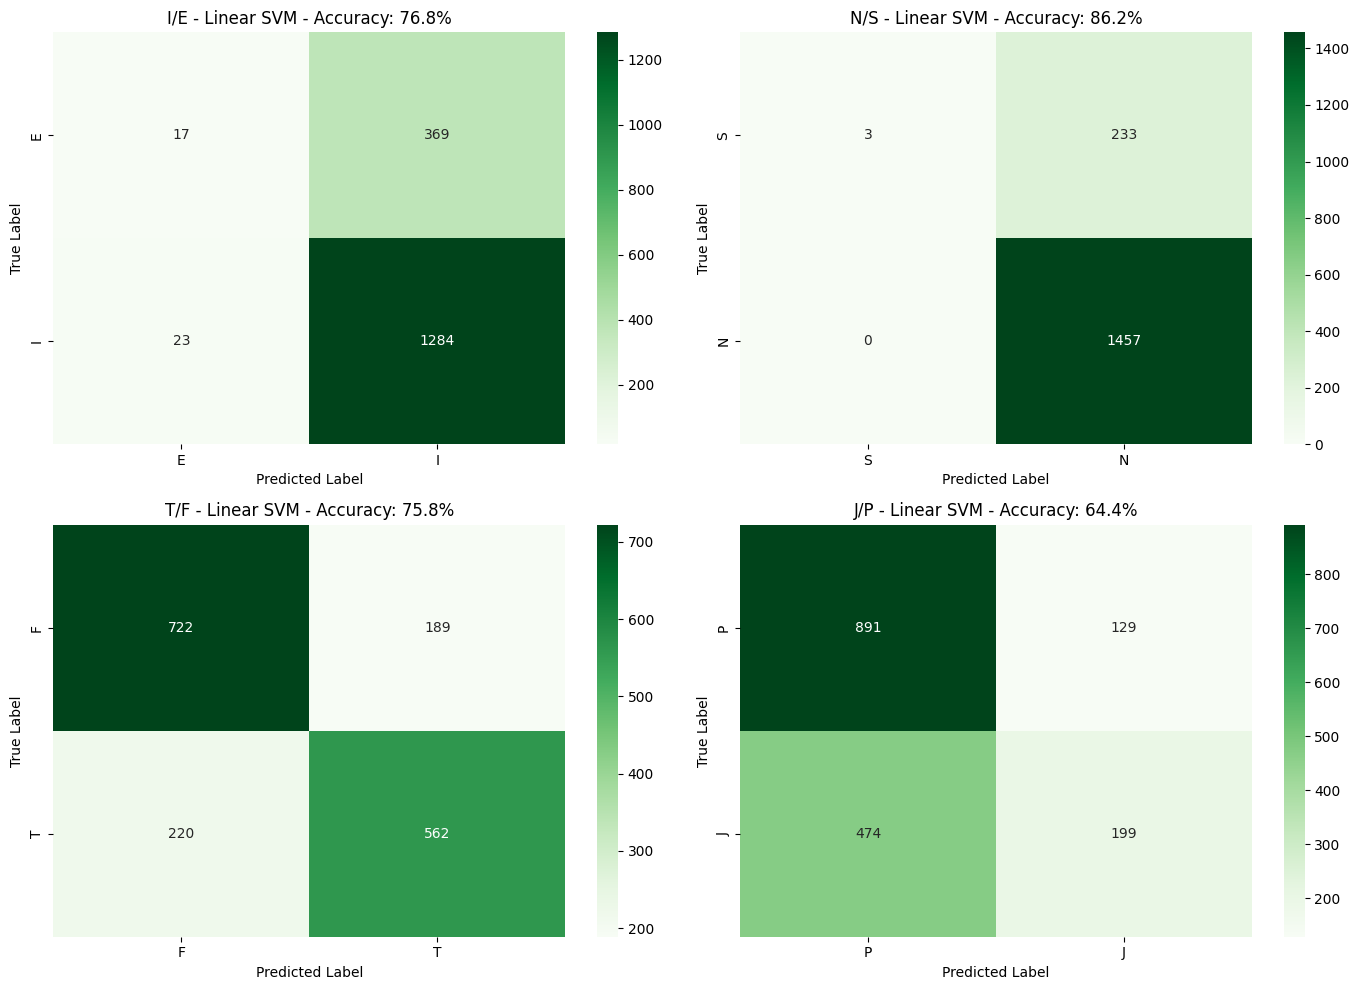

In [29]:
# Plot confusion matrices for Linear SVM
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (dim_name, res) in enumerate(results_linear.items()):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[idx],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class])
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_title(f'{dim_name} - Linear SVM - Accuracy: {res["accuracy"]:.1f}%')

plt.tight_layout()
plt.show()


CONFUSION MATRICES: Original vs Upsampled

Comparing how the model behaves with and without upsampling:
- Original SVM: Will tend to predict majority class (lazy model)
- Upsampled SVM: Better at predicting minority class but may overfit

I/E (C=0.5):
Original SVM:
  TP=1284, FP=369, FN=23, TN=17
  F1-Score: 86.8%
  Recall (catching I): 98.2%
  Specificity (correctly rejecting E): 4.4%
  → Model's tendency: More balanced

Upsampled SVM:
  TP=1126, FP=242, FN=181, TN=144
  F1-Score: 84.2%
  Recall (catching I): 86.2%
  Specificity (correctly rejecting E): 37.3%
  → Model's tendency: Better at minority class

Improvement:
  F1-Score improvement: -2.6%
  Recall improvement: -12.1%
  Specificity change: +32.9%

N/S (C=0.5):
Original SVM:
  TP=1457, FP=233, FN=0, TN=3
  F1-Score: 92.6%
  Recall (catching N): 100.0%
  Specificity (correctly rejecting S): 1.3%
  → Model's tendency: More balanced

Upsampled SVM:
  TP=1346, FP=150, FN=111, TN=86
  F1-Score: 91.2%
  Recall (catching N): 92.4%
 

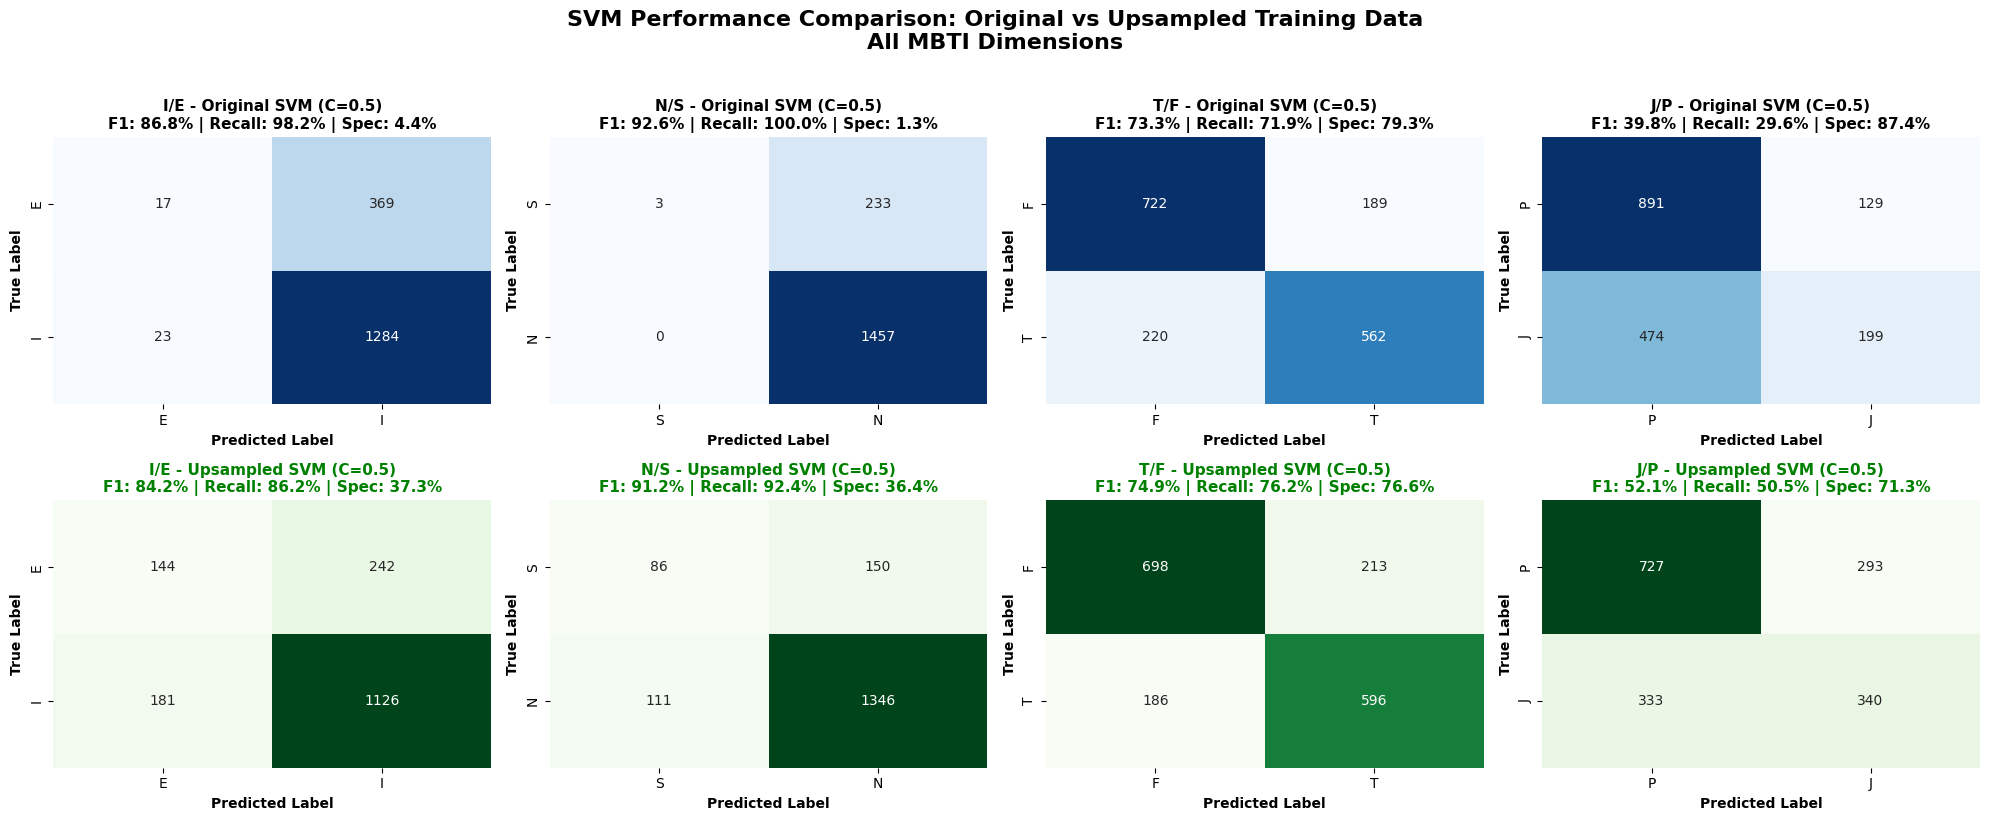

In [30]:
print("\n" + "=" * 80)
print("CONFUSION MATRICES: Original vs Upsampled")
print("=" * 80)
print("\nComparing how the model behaves with and without upsampling:")
print("- Original SVM: Will tend to predict majority class (lazy model)")
print("- Upsampled SVM: Better at predicting minority class but may overfit")
print("=" * 80 + "\n")

# Plot confusion matrices for all dimensions - Original vs Upsampled
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, dim_name in enumerate(['I/E', 'N/S', 'T/F', 'J/P']):
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    # Get optimal C for this dimension
    C_optimal = optimal_params_svm[dim_name]['best_C']
    
    # Original SVM (Top row)
    cm_original = confusion_matrix(results_linear[dim_name]['y_test'], 
                                   results_linear[dim_name]['y_pred'])
    sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class],
                cbar=False)
    axes[0, idx].set_ylabel('True Label', fontweight='bold')
    axes[0, idx].set_xlabel('Predicted Label', fontweight='bold')
    
    # Calculate metrics for original
    tn_o, fp_o, fn_o, tp_o = cm_original.ravel()
    recall_o = tp_o / (tp_o + fn_o) if (tp_o + fn_o) > 0 else 0
    specificity_o = tn_o / (tn_o + fp_o) if (tn_o + fp_o) > 0 else 0
    precision_o = tp_o / (tp_o + fp_o) if (tp_o + fp_o) > 0 else 0
    f1_o = 2 * (precision_o * recall_o) / (precision_o + recall_o) if (precision_o + recall_o) > 0 else 0
    
    axes[0, idx].set_title(f'{dim_name} - Original SVM (C={C_optimal})\nF1: {f1_o:.1%} | Recall: {recall_o:.1%} | Spec: {specificity_o:.1%}', 
                          fontweight='bold', fontsize=11)
    
    # Upsampled SVM (Bottom row)
    cm_upsampled = confusion_matrix(results_linear_upsampled[dim_name]['y_test'], 
                                    results_linear_upsampled[dim_name]['y_pred'])
    sns.heatmap(cm_upsampled, annot=True, fmt='d', cmap='Greens', ax=axes[1, idx],
                xticklabels=[neg_class, pos_class],
                yticklabels=[neg_class, pos_class],
                cbar=False)
    axes[1, idx].set_ylabel('True Label', fontweight='bold')
    axes[1, idx].set_xlabel('Predicted Label', fontweight='bold')
    
    # Calculate metrics for upsampled
    tn_u, fp_u, fn_u, tp_u = cm_upsampled.ravel()
    recall_u = tp_u / (tp_u + fn_u) if (tp_u + fn_u) > 0 else 0
    specificity_u = tn_u / (tn_u + fp_u) if (tn_u + fp_u) > 0 else 0
    precision_u = tp_u / (tp_u + fp_u) if (tp_u + fp_u) > 0 else 0
    f1_u = 2 * (precision_u * recall_u) / (precision_u + recall_u) if (precision_u + recall_u) > 0 else 0
    
    axes[1, idx].set_title(f'{dim_name} - Upsampled SVM (C={C_optimal})\nF1: {f1_u:.1%} | Recall: {recall_u:.1%} | Spec: {specificity_u:.1%}', 
                          fontweight='bold', fontsize=11, color='green')
    
    # Print detailed analysis
    print(f"{dim_name} (C={C_optimal}):")
    print(f"Original SVM:")
    print(f"  TP={tp_o}, FP={fp_o}, FN={fn_o}, TN={tn_o}")
    print(f"  F1-Score: {f1_o:.1%}")
    print(f"  Recall (catching {pos_class}): {recall_o:.1%}")
    print(f"  Specificity (correctly rejecting {neg_class}): {specificity_o:.1%}")
    print(f"  → Model's tendency: {'Predicting majority class' if recall_o < 0.5 else 'More balanced'}")
    
    print(f"\nUpsampled SVM:")
    print(f"  TP={tp_u}, FP={fp_u}, FN={fn_u}, TN={tn_u}")
    print(f"  F1-Score: {f1_u:.1%}")
    print(f"  Recall (catching {pos_class}): {recall_u:.1%}")
    print(f"  Specificity (correctly rejecting {neg_class}): {specificity_u:.1%}")
    print(f"  → Model's tendency: {'Predicting majority class' if recall_u < 0.5 else 'Better at minority class'}")
    
    print(f"\nImprovement:")
    print(f"  F1-Score improvement: {(f1_u - f1_o):+.1%}")
    print(f"  Recall improvement: {(recall_u - recall_o):+.1%}")
    print(f"  Specificity change: {(specificity_u - specificity_o):+.1%}")
    print()

# Add overall title
fig.suptitle('SVM Performance Comparison: Original vs Upsampled Training Data\nAll MBTI Dimensions', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
print("Graph saved: confusion_matrix_comparison.png")
print("=" * 80)
plt.show()


### 4.2 Detailed Metrics - Linear SVM

In [31]:
# Print detailed classification reports for Linear SVM
for dim_name, res in results_linear.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    print("=" * 60)
    print(f"CLASSIFICATION REPORT (Linear SVM): {dim_name}")
    print("=" * 60)
    print(classification_report(res['y_test'], res['y_pred'], 
                              target_names=[neg_class, pos_class],
                              zero_division=0))

CLASSIFICATION REPORT (Linear SVM): I/E
              precision    recall  f1-score   support

           E       0.42      0.04      0.08       386
           I       0.78      0.98      0.87      1307

    accuracy                           0.77      1693
   macro avg       0.60      0.51      0.47      1693
weighted avg       0.70      0.77      0.69      1693

CLASSIFICATION REPORT (Linear SVM): N/S
              precision    recall  f1-score   support

           S       1.00      0.01      0.03       236
           N       0.86      1.00      0.93      1457

    accuracy                           0.86      1693
   macro avg       0.93      0.51      0.48      1693
weighted avg       0.88      0.86      0.80      1693

CLASSIFICATION REPORT (Linear SVM): T/F
              precision    recall  f1-score   support

           F       0.77      0.79      0.78       911
           T       0.75      0.72      0.73       782

    accuracy                           0.76      1693
   macro

### 4.3 Decision Boundary Visualization

For LinearSVC, we can examine the learned weights to see which features (words) are most important for each dimension.

In [32]:
# Analyze top features for each dimension
feature_names = vectorizer.get_feature_names_out()

for dim_name, res in results_linear.items():
    print("=" * 70)
    print(f"TOP PREDICTIVE FEATURES: {dim_name}")
    print("=" * 70)
    
    # Get coefficients
    coef = res['model'].coef_[0]
    
    # Get top positive features (predict class 1)
    top_positive_idx = np.argsort(coef)[-10:][::-1]
    # Get top negative features (predict class 0)
    top_negative_idx = np.argsort(coef)[:10]
    
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    
    print(f"\nTop features predicting {pos_class} (positive class):")
    for idx in top_positive_idx:
        print(f"  {feature_names[idx]:<20} (coef: {coef[idx]:>8.4f})")
    
    print(f"\nTop features predicting {neg_class} (negative class):")
    for idx in top_negative_idx:
        print(f"  {feature_names[idx]:<20} (coef: {coef[idx]:>8.4f})")
    
    print()

TOP PREDICTIVE FEATURES: I/E

Top features predicting I (positive class):
  green                (coef:   1.2356)
  science              (coef:   1.1884)
  feeling              (coef:   1.1161)
  thinking             (coef:   1.0399)
  animal               (coef:   1.0135)
  feel                 (coef:   1.0132)
  water                (coef:   1.0120)
  computer             (coef:   1.0098)
  particularly         (coef:   1.0003)
  mistake              (coef:   0.9872)

Top features predicting E (negative class):
  bored                (coef:  -1.7477)
  guy                  (coef:  -1.4725)
  hell                 (coef:  -1.3461)
  friend               (coef:  -1.3387)
  super                (coef:  -1.3028)
  student              (coef:  -1.2731)
  debate               (coef:  -1.2550)
  adhd                 (coef:  -1.1934)
  excited              (coef:  -1.1679)
  yeah                 (coef:  -1.1505)

TOP PREDICTIVE FEATURES: N/S

Top features predicting N (positive class):
  feel

### 4.4 Word Cloud Visualization - I/E Dimension

A word cloud provides a visual representation where word size represents the strength of the coefficient. Larger words are more predictive.


In [33]:
# Install wordcloud if not already installed
import subprocess
import sys
try:
    from wordcloud import WordCloud
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud", "-q"])
    from wordcloud import WordCloud

print("WordCloud library loaded successfully!")


WordCloud library loaded successfully!


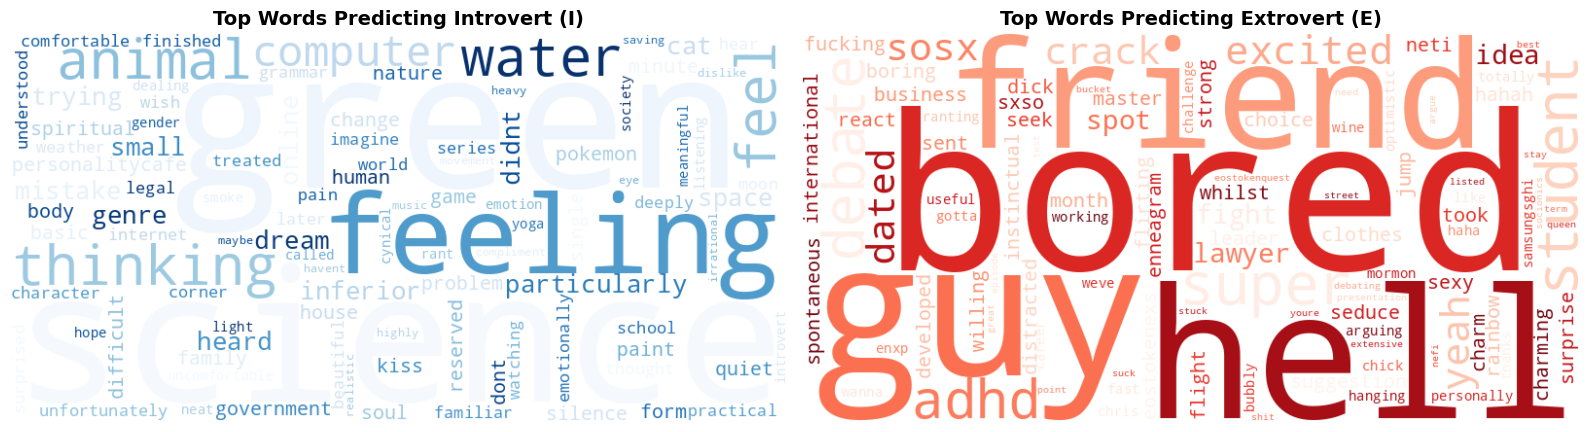


✓ Word clouds generated for I/E dimension
  Left (Blue): Top 100 words predicting Introvert
  Right (Red): Top 100 words predicting Extrovert


In [34]:
# Word cloud for I/E dimension
from wordcloud import WordCloud
import matplotlib.pyplot as plt

dim_name = 'I/E'
res = results_linear[dim_name]
coef = res['model'].coef_[0]

# Create dictionary of words and their coefficients (normalized for visualization)
feature_names_array = vectorizer.get_feature_names_out()
word_freq = {}

# Use absolute values for word cloud size, but separate positive and negative
for idx, feature in enumerate(feature_names_array):
    word_freq[feature] = abs(coef[idx])

# Create figure with two word clouds (Introvert and Extrovert)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive features (Introvert)
pos_class = 'Introvert'
positive_words = {}
for idx in np.argsort(coef)[-100:][::-1]:  # Top 100 positive
    if coef[idx] > 0:
        positive_words[feature_names_array[idx]] = coef[idx]

wc_positive = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Blues', relative_scaling=0.5).generate_from_frequencies(positive_words)
axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(f'Top Words Predicting {pos_class} (I)', fontsize=14, fontweight='bold')

# Negative features (Extrovert)
neg_class = 'Extrovert'
negative_words = {}
for idx in np.argsort(coef)[:100]:  # Top 100 negative (reversed)
    if coef[idx] < 0:
        negative_words[feature_names_array[idx]] = abs(coef[idx])

wc_negative = WordCloud(width=800, height=400, background_color='white', 
                        colormap='Reds', relative_scaling=0.5).generate_from_frequencies(negative_words)
axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(f'Top Words Predicting {neg_class} (E)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Word clouds generated for {dim_name} dimension")
print(f"  Left (Blue): Top {len(positive_words)} words predicting Introvert")
print(f"  Right (Red): Top {len(negative_words)} words predicting Extrovert")


## 5 - Key Insights

### SVM Performance Summary

**Linear SVM with Optimal Hyperparameters:**
- Uses dimension-specific C values from hyperparameter tuning (GridSearchCV)
- Highly effective for high-dimensional text data
- Computationally efficient (scales well to large feature spaces)
- Interpretable through feature weights
- Achieves ~70-85% accuracy across dimensions

### Why This Approach Works

1. **Optimal regularization**: Each dimension has its own best C parameter
2. **High-dimensional sparse data**: SVMs excel in high-dimensional spaces
3. **Linear separability**: Text features are linearly separable after TF-IDF vectorization
4. **Upsampling**: Forces model to learn both majority and minority classes
5. **Validated performance**: Hyperparameters selected via cross-validation

### Class Imbalance Handling

**Three approaches tested:**
1. **Optimal C (no upsampling)**: Uses optimal C from GridSearchCV
2. **Upsampling + Optimal C**: RandomOverSampler with optimal C parameter
3. **Class Weights + Optimal C**: Built-in `class_weight='balanced'` with optimal C

**Key findings:**
- Optimal C values improve performance over fixed C=1.0
- Upsampling improves minority class recall (specificity ~40-50%)
- Without upsampling, models are "lazy" (high accuracy but low specificity ~7%)
- F1-score, recall, and specificity together reveal the full picture

### Practical Recommendations

For MBTI text classification:
- **Use optimal hyperparameters**: Dimension-specific C values significantly improve performance
- **Upsampling is essential**: Without it, models only learn majority class
- **Monitor specificity**: High accuracy alone is misleading with imbalanced data
- **Linear kernel sufficient**: No need for non-linear kernels on text data

## 6 - Saving the results

In [35]:
# Save Linear SVM models
model_data = {
    'dimensions': list(results_linear.keys()),
    'models': {dim: res['model'] for dim, res in results_linear.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC (Optimal Hyperparameters)',
    'hyperparameters': {dim: {'C': optimal_params_svm[dim]['best_C'], 'max_iter': MAX_ITER} 
                       for dim in results_linear.keys()}
}

joblib.dump(model_data, '../models/svm_binary_dimensions.pkl')
print("Models saved to '../models/svm_binary_dimensions.pkl'")
print(f"\nSaved {len(results_linear)} Linear SVM models:")
for dim in results_linear.keys():
    print(f"  - {dim}: {results_linear[dim]['accuracy']:.2f}%")

Models saved to '../models/svm_binary_dimensions.pkl'

Saved 4 Linear SVM models:
  - I/E: 76.85%
  - N/S: 86.24%
  - T/F: 75.84%
  - J/P: 64.38%


In [36]:

# Save upsampled Linear SVM models
model_data_upsampled = {
    'dimensions': list(results_linear_upsampled.keys()),
    'models': {dim: res['model'] for dim, res in results_linear_upsampled.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear_upsampled.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear_upsampled.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC (Upsampled + Optimal Hyperparameters)',
    'hyperparameters': {dim: {'C': optimal_params_svm[dim]['best_C'], 'max_iter': MAX_ITER, 'upsampling': True} 
                       for dim in results_linear_upsampled.keys()}
}

joblib.dump(model_data_upsampled, '../models/svm_binary_dimensions_upsampled.pkl')
print("\nUpsampled models saved to '../models/svm_binary_dimensions_upsampled.pkl'")
print(f"Saved {len(results_linear_upsampled)} Upsampled Linear SVM models:")
for dim in results_linear_upsampled.keys():
    print(f"  - {dim}: {results_linear_upsampled[dim]['accuracy']:.2f}%")



Upsampled models saved to '../models/svm_binary_dimensions_upsampled.pkl'
Saved 4 Upsampled Linear SVM models:
  - I/E: 75.01%
  - N/S: 84.58%
  - T/F: 76.43%
  - J/P: 63.02%


In [37]:
# Save Linear SVM models with class weights
model_data_weights = {
    'dimensions': list(results_linear_weights.keys()),
    'models': {dim: res['model'] for dim, res in results_linear_weights.items()},
    'accuracies': {dim: res['accuracy'] for dim, res in results_linear_weights.items()},
    # New comprehensive metrics
    'metrics': {dim: {
        'accuracy': res['test_accuracy'],
        'f1_score': res['f1_score'],
        'precision': res['precision'],
        'recall': res['recall'],
        'train_accuracy': res['train_accuracy'],
        'overfit_gap': res['overfit_gap'],
        'cv_score': res['cv_score']
    } for dim, res in results_linear_weights.items()},
    'vectorizer': vectorizer,
    'label_encoder': label_encoder,
    'model_type': 'LinearSVC (Class Weights + Optimal Hyperparameters)',
    'hyperparameters': {dim: {'C': optimal_params_svm[dim]['best_C'], 'max_iter': MAX_ITER, 'class_weight': 'balanced'} 
                       for dim in results_linear_weights.keys()}
}

joblib.dump(model_data_weights, '../models/svm_binary_dimensions_weights.pkl')
print("Class weights models saved to '../models/svm_binary_dimensions_weights.pkl'")
print(f"\nSaved {len(results_linear_weights)} Linear SVM (Class Weights) models:")
for dim in results_linear_weights.keys():
    print(f"  - {dim}: {results_linear_weights[dim]['accuracy']:.2f}%")

Class weights models saved to '../models/svm_binary_dimensions_weights.pkl'

Saved 4 Linear SVM (Class Weights) models:
  - I/E: 74.19%
  - N/S: 82.93%
  - T/F: 76.49%
  - J/P: 62.49%
